In [1]:
%matplotlib inline 
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image




# 1 -  Exploration

In [2]:
df = pd.read_csv("data/digits-raw.csv", header=None)
np.random.seed(0)

max_label = df[1].max()
# print(max_label)
random_imgs = []

#print(df[df[1] == 10])

for i in range(max_label+1):
    df_i = df[df[1] == i]
    if df_i.empty is True:
        continue
    img = df_i.sample()
    # Drop the first two columns (id and label)
    img = img.iloc[:,2:]
    # Reshape as 28x28
    img = np.reshape(img, (28,28))
    # Show inline
    x = Image.fromarray(np.uint8(img), 'L')
    display(x)

# img = df.iloc[100][2:]
# img = np.reshape(img, (28,28))

# img



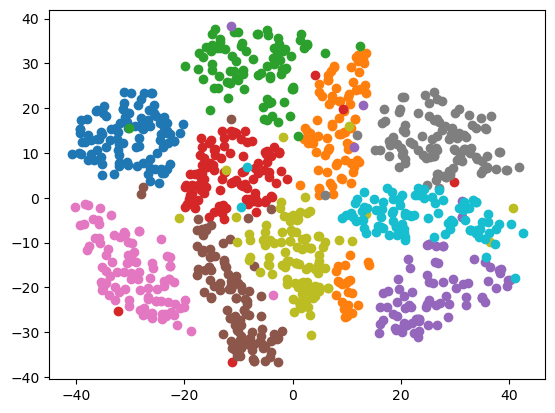

In [3]:
samples = np.random.randint(0, df.shape[0], size=1000)
df_emb = pd.read_csv("data/digits-embedding.csv", header=None)
dots = []

max_label = df_emb[1].max()
# print(max_label)
labeled_dots = {}
for i in range(max_label+1):
    labeled_dots[i] = {'x' : [], 'y': []}

dot = df_emb.iloc[500]
for i in samples:
    dot = df_emb.iloc[i]
    labeled_dots[dot[1]]['x'].append(dot[2])
    labeled_dots[dot[1]]['y'].append(dot[3])

for i in range(max_label+1):
    plt.plot(labeled_dots[i]["x"], labeled_dots[i]["y"], 'o')
plt.show()


In [60]:
def dist(x, y):
    return np.sqrt((x[0] - y[0]) ** 2 + (x[1] - y[1]) ** 2)

In [63]:

def make_clusters(df, clusters):
    centroids = clusters.keys()
    # cluster data with nearest centroid
    for i, row in df.iterrows():
        # print(f'point: {i} ', end='')
        p = (float(row[2]), float(row[3]))
        closest_centroid = -1
        # closest centroid distance
        cc_dist = np.finfo(np.float64).max
        # find the nearest centroid
        for (ci, c) in enumerate(centroids):
            p_c = df.iloc[c][2], df.iloc[c][3]
            d = dist(p, p_c)
            # print(f'd{ci}: {d} ', end='')
            if d < cc_dist:
                closest_centroid = c
                cc_dist = d
            
        # add to the cluster found
        clusters[closest_centroid].append(i) 
        # print(f"closest: {cc_dist}")
        # print(row[2], row[3])

    return clusters


In [65]:
# def kmeans(df, k=10, max_it=50):
k = 10
max_it = 50
df = df_emb

centroids = np.random.randint(0, df.shape[0], size=k)
# print(centroids)

clusters = {}
for c in centroids:
    clusters[c] = []
    # print(df.iloc[c][2:])

clusters = make_clusters(df, clusters)


In [67]:
s = 0
for i, c in enumerate(clusters.keys()):
    l = len(clusters[c])
    print(f'cluster{i} size: {l}')
    s += l

if(s == len(df)):
    print("all data was properly clustered")
else:
    print("mismatch in final size of clusters")

cluster0 size: 333
cluster1 size: 1814
cluster2 size: 735
cluster3 size: 2425
cluster4 size: 1726
cluster5 size: 3660
cluster6 size: 558
cluster7 size: 2900
cluster8 size: 2438
cluster9 size: 3411
all data was properly clustered
